In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [2]:
db_path = "../data/btc_prices.sqlite3"
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM price_snapshots", conn)

In [3]:
df.head()

,id,asset,measurement_timestamp,filtered_timestamp,observed_market_type,observed_asset,observed_bid_price,observed_bid_size,observed_ask_price,observed_ask_size,...,midprice_filtered_timestamp,midprice_filtered_price,midprice_basis,microprice_1p5x_filtered_timestamp,microprice_1p5x_filtered_price,microprice_1p5x_basis,microprice_3x_filtered_timestamp,microprice_3x_filtered_price,microprice_3x_basis,recorded_at_ms
0,1,BTC,1774800195022,1774800195022,spot,BTC,66517.0,0.25839,66518.0,0.17042,...,1774800195022,66517.5,11.0,1774800195022,66517.602569,11.000017,1774800195022,66517.602564,11.000017,1774800195243
1,2,BTC,1774800195022,1774800195022,perp,BTC,66528.0,3.70558,66529.0,9.38021,...,1774800195022,66517.5,11.0,1774800195022,66517.602565,10.680612,1774800195022,66517.602556,10.680622,1774800195553
2,3,BTC,1774800195152,1774800195152,perp,BTC,66528.0,3.68066,66529.0,9.38021,...,1774800195152,66517.5,11.0,1774800195152,66517.602182,10.679641,1774800195152,66517.602174,10.679651,1774800195555
3,4,BTC,1774800195327,1774800195327,perp,BTC,66528.0,3.68066,66529.0,9.60567,...,1774800195327,66517.5,11.0,1774800195327,66517.600823,10.676241,1774800195327,66517.600816,10.676255,1774800195633
4,5,BTC,1774800195518,1774800195518,perp,BTC,66528.0,3.68066,66529.0,9.38021,...,1774800195518,66517.5,11.0,1774800195518,66517.602168,10.679605,1774800195518,66517.602158,10.679610,1774800195825


In [4]:
df = df.sort_values(["measurement_timestamp", "recorded_at_ms"]).reset_index(drop=True)
df = df[df["measurement_timestamp"].notna()].copy()

df["ts"] = pd.to_datetime(df["measurement_timestamp"], unit="ms", utc=True)

if {"perp_price", "spot_price"}.issubset(df.columns):
    df["raw_mid_spread"] = df["perp_price"] - df["spot_price"]

if {"perp_microprice", "spot_microprice"}.issubset(df.columns):
    df["raw_micro_spread"] = df["perp_microprice"] - df["spot_microprice"]

required = ["measurement_timestamp"]
if "raw_mid_spread" in df.columns:
    required.append("raw_mid_spread")

df = df.dropna(subset=required).copy()
df.head()

,id,asset,measurement_timestamp,filtered_timestamp,observed_market_type,observed_asset,observed_bid_price,observed_bid_size,observed_ask_price,observed_ask_size,...,microprice_1p5x_filtered_timestamp,microprice_1p5x_filtered_price,microprice_1p5x_basis,microprice_3x_filtered_timestamp,microprice_3x_filtered_price,microprice_3x_basis,recorded_at_ms,ts,raw_mid_spread,raw_micro_spread
1,2,BTC,1774800195022,1774800195022,perp,BTC,66528.0,3.70558,66529.0,9.38021,...,1774800195022,66517.602565,10.680612,1774800195022,66517.602556,10.680622,1774800195553,2026-03-29 16:03:15.022000+00:00,11.0,10.680601
2,3,BTC,1774800195152,1774800195152,perp,BTC,66528.0,3.68066,66529.0,9.38021,...,1774800195152,66517.602182,10.679641,1774800195152,66517.602174,10.679651,1774800195555,2026-03-29 16:03:15.152000+00:00,11.0,10.679234
3,4,BTC,1774800195327,1774800195327,perp,BTC,66528.0,3.68066,66529.0,9.60567,...,1774800195327,66517.600823,10.676241,1774800195327,66517.600816,10.676255,1774800195633,2026-03-29 16:03:15.327000+00:00,11.0,10.674452
4,5,BTC,1774800195518,1774800195518,perp,BTC,66528.0,3.68066,66529.0,9.38021,...,1774800195518,66517.602168,10.679605,1774800195518,66517.602158,10.679610,1774800195825,2026-03-29 16:03:15.518000+00:00,11.0,10.679234
5,6,BTC,1774800195716,1774800195716,perp,BTC,66528.0,3.67766,66529.0,11.10994,...,1774800195716,66517.592787,10.656147,1774800195716,66517.592785,10.656172,1774800196076,2026-03-29 16:03:15.716000+00:00,11.0,10.646124


In [5]:
HORIZONS_MS = [250, 1000, 5000]
def add_future_target(frame: pd.DataFrame, value_col: str, horizon_ms: int, out_col: str) -> pd.DataFrame:
    left = frame[["measurement_timestamp"]].copy()
    left["target_ts"] = left["measurement_timestamp"] + horizon_ms

    right = frame[["measurement_timestamp", value_col]].copy().rename(
        columns={"measurement_timestamp": "future_measurement_timestamp", value_col: out_col}
    )

    merged = pd.merge_asof(
        left.sort_values("target_ts"),
        right.sort_values("future_measurement_timestamp"),
        left_on="target_ts",
        right_on="future_measurement_timestamp",
        direction="forward",
        allow_exact_matches=True,
    )

    frame = frame.copy()
    frame[out_col] = merged[out_col].values
    frame[f"{out_col}_actual_horizon_ms"] = (
        merged["future_measurement_timestamp"].values - frame["measurement_timestamp"].values
    )
    return frame


for h in HORIZONS_MS:
    if "raw_mid_spread" in df.columns:
        df = add_future_target(df, "raw_mid_spread", h, f"raw_mid_spread_fwd_{h}ms")
    if "raw_micro_spread" in df.columns:
        df = add_future_target(df, "raw_micro_spread", h, f"raw_micro_spread_fwd_{h}ms")

display(df.filter(regex="raw_.*fwd").head())

,raw_mid_spread_fwd_250ms,raw_mid_spread_fwd_250ms_actual_horizon_ms,raw_micro_spread_fwd_250ms,raw_micro_spread_fwd_250ms_actual_horizon_ms,raw_mid_spread_fwd_1000ms,raw_mid_spread_fwd_1000ms_actual_horizon_ms,raw_micro_spread_fwd_1000ms,raw_micro_spread_fwd_1000ms_actual_horizon_ms,raw_mid_spread_fwd_5000ms,raw_mid_spread_fwd_5000ms_actual_horizon_ms,raw_micro_spread_fwd_5000ms,raw_micro_spread_fwd_5000ms_actual_horizon_ms
1,11.0,305.0,10.674452,305.0,11.0,1038.0,10.649821,1038.0,11.5,5008.0,9.235623,5008.0
2,11.0,366.0,10.679234,366.0,11.0,1108.0,10.637425,1108.0,11.5,5023.0,9.235628,5023.0
3,11.0,389.0,10.646124,389.0,11.0,1706.0,10.678877,1706.0,11.5,5021.0,9.235705,5021.0
4,11.0,303.0,10.674125,303.0,11.0,1515.0,10.678877,1515.0,11.5,5032.0,9.235737,5032.0
5,11.0,344.0,10.649821,344.0,11.0,1317.0,10.678877,1317.0,11.5,5033.0,9.235687,5033.0


In [6]:
# Cell 6: metric helpers

def rmse(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((x[mask] - y[mask]) ** 2)))

def mae(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(x[mask] - y[mask])))

def corr(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan
    return float(np.corrcoef(x[mask], y[mask])[0, 1])

def jitter_std(x):
    dx = np.diff(np.asarray(x, dtype=float))
    dx = dx[np.isfinite(dx)]
    if len(dx) == 0:
        return np.nan
    return float(np.std(dx))

def total_variation(x):
    dx = np.diff(np.asarray(x, dtype=float))
    dx = dx[np.isfinite(dx)]
    if len(dx) == 0:
        return np.nan
    return float(np.sum(np.abs(dx)))

def summarize_filter(df: pd.DataFrame, basis_col: str) -> dict:
    out = {"filter": basis_col}

    x = df[basis_col].to_numpy(dtype=float)

    # contemporaneous fit to observable raw spreads
    if "raw_mid_spread" in df.columns:
        out["rmse_vs_raw_mid"] = rmse(x, df["raw_mid_spread"].to_numpy(dtype=float))
        out["mae_vs_raw_mid"] = mae(x, df["raw_mid_spread"].to_numpy(dtype=float))
        out["corr_vs_raw_mid"] = corr(x, df["raw_mid_spread"].to_numpy(dtype=float))

    if "raw_micro_spread" in df.columns:
        out["rmse_vs_raw_micro"] = rmse(x, df["raw_micro_spread"].to_numpy(dtype=float))
        out["mae_vs_raw_micro"] = mae(x, df["raw_micro_spread"].to_numpy(dtype=float))
        out["corr_vs_raw_micro"] = corr(x, df["raw_micro_spread"].to_numpy(dtype=float))

    # smoothness / jitter
    out["jitter_std"] = jitter_std(x)
    out["total_variation"] = total_variation(x)

    if "raw_mid_spread" in df.columns:
        raw_dx_std = jitter_std(df["raw_mid_spread"].to_numpy(dtype=float))
        out["jitter_ratio_vs_raw_mid"] = out["jitter_std"] / raw_dx_std if raw_dx_std and np.isfinite(raw_dx_std) else np.nan

    # predictive usefulness against future raw spread
    for h in HORIZONS_MS:
        mid_col = f"raw_mid_spread_fwd_{h}ms"
        mic_col = f"raw_micro_spread_fwd_{h}ms"

        if mid_col in df.columns:
            out[f"rmse_vs_future_raw_mid_{h}ms"] = rmse(x, df[mid_col].to_numpy(dtype=float))
            out[f"corr_vs_future_raw_mid_{h}ms"] = corr(x, df[mid_col].to_numpy(dtype=float))

        if mic_col in df.columns:
            out[f"rmse_vs_future_raw_micro_{h}ms"] = rmse(x, df[mic_col].to_numpy(dtype=float))
            out[f"corr_vs_future_raw_micro_{h}ms"] = corr(x, df[mic_col].to_numpy(dtype=float))

    return out

In [7]:
# Cell 7: run the comparison

candidate_basis_cols = [
    c for c in [
        "basis",
        "midprice_basis",
        "microprice_1p5x_basis",
        "microprice_3x_basis",
    ]
    if c in df.columns
]

results = pd.DataFrame([summarize_filter(df, c) for c in candidate_basis_cols])

display(results.T)

,0,1,2,3
filter,basis,midprice_basis,microprice_1p5x_basis,microprice_3x_basis
rmse_vs_raw_mid,1.31407,1.31407,1.472009,1.553786
mae_vs_raw_mid,0.420173,0.420173,0.72876,0.763843
corr_vs_raw_mid,0.962914,0.962914,0.955076,0.949403
rmse_vs_raw_micro,1.8863,1.8863,1.755679,1.85918
mae_vs_raw_micro,0.862886,0.862886,0.533635,0.586585
corr_vs_raw_micro,0.92301,0.92301,0.931603,0.922836
jitter_std,0.768372,0.768372,0.775154,0.76107
total_variation,4313.379077,4313.379077,4774.838589,4658.386371
jitter_ratio_vs_raw_mid,0.693235,0.693235,0.699354,0.686648


In [8]:
# Cell 8: build a simple ranking score
# lower RMSE/MAE/jitter is better; higher correlation is better

rank_df = results.copy()

lower_is_better = [
    c for c in rank_df.columns
    if c.startswith("rmse_") or c.startswith("mae_") or c in ["jitter_std", "total_variation", "jitter_ratio_vs_raw_mid"]
]

higher_is_better = [
    c for c in rank_df.columns
    if c.startswith("corr_")
]

for c in lower_is_better:
    rank_df[c + "_rank"] = rank_df[c].rank(method="average", ascending=True)

for c in higher_is_better:
    rank_df[c + "_rank"] = rank_df[c].rank(method="average", ascending=False)

rank_cols = [c for c in rank_df.columns if c.endswith("_rank")]
rank_df["composite_rank_score"] = rank_df[rank_cols].mean(axis=1)

ranking = rank_df[["filter", "composite_rank_score"]].sort_values("composite_rank_score")
display(ranking)

,filter,composite_rank_score
2,microprice_1p5x_basis,2.095238
3,microprice_3x_basis,2.619048
0,basis,2.642857
1,midprice_basis,2.642857


In [9]:
# Cell 9: look at the most important subset of metrics only

important_cols = [
    "filter",
    "rmse_vs_raw_mid",
    "rmse_vs_future_raw_mid_250ms",
    "rmse_vs_future_raw_mid_1000ms",
    "rmse_vs_future_raw_mid_5000ms",
    "corr_vs_future_raw_mid_250ms",
    "corr_vs_future_raw_mid_1000ms",
    "corr_vs_future_raw_mid_5000ms",
    "jitter_std",
    "jitter_ratio_vs_raw_mid",
]

important_cols = [c for c in important_cols if c in results.columns]
display(results[important_cols].sort_values("rmse_vs_future_raw_mid_1000ms"))

,filter,rmse_vs_raw_mid,rmse_vs_future_raw_mid_250ms,rmse_vs_future_raw_mid_1000ms,rmse_vs_future_raw_mid_5000ms,corr_vs_future_raw_mid_250ms,corr_vs_future_raw_mid_1000ms,corr_vs_future_raw_mid_5000ms,jitter_std,jitter_ratio_vs_raw_mid
2,microprice_1p5x_basis,1.472009,2.242545,3.077749,4.336837,0.889959,0.782756,0.552596,0.775154,0.699354
3,microprice_3x_basis,1.553786,2.302238,3.096663,4.334625,0.883652,0.779737,0.552263,0.761070,0.686648
0,basis,1.314070,2.213386,3.109236,4.436397,0.893163,0.783125,0.547728,0.768372,0.693235
1,midprice_basis,1.314070,2.213386,3.109236,4.436397,0.893163,0.783125,0.547728,0.768372,0.693235


Winner by composite score: microprice_1p5x_basis


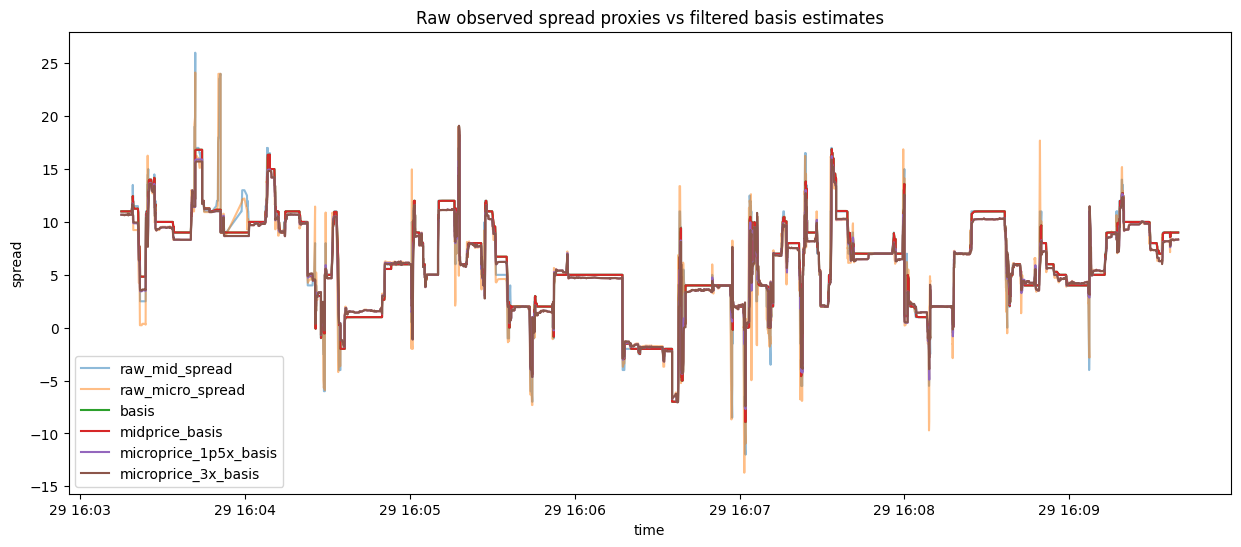

In [10]:
# Cell 10: plot a window so you can visually inspect the winner

winner = ranking.iloc[0]["filter"]
print("Winner by composite score:", winner)

# choose a plotting window
plot_n = min(len(df), 3000)
plot_df = df.iloc[:plot_n].copy()

plt.figure(figsize=(15, 6))
plt.plot(plot_df["ts"], plot_df["raw_mid_spread"], label="raw_mid_spread", alpha=0.5)
if "raw_micro_spread" in plot_df.columns:
    plt.plot(plot_df["ts"], plot_df["raw_micro_spread"], label="raw_micro_spread", alpha=0.5)

for c in candidate_basis_cols:
    plt.plot(plot_df["ts"], plot_df[c], label=c, linewidth=1.5)

plt.title("Raw observed spread proxies vs filtered basis estimates")
plt.xlabel("time")
plt.ylabel("spread")
plt.legend()
plt.show()

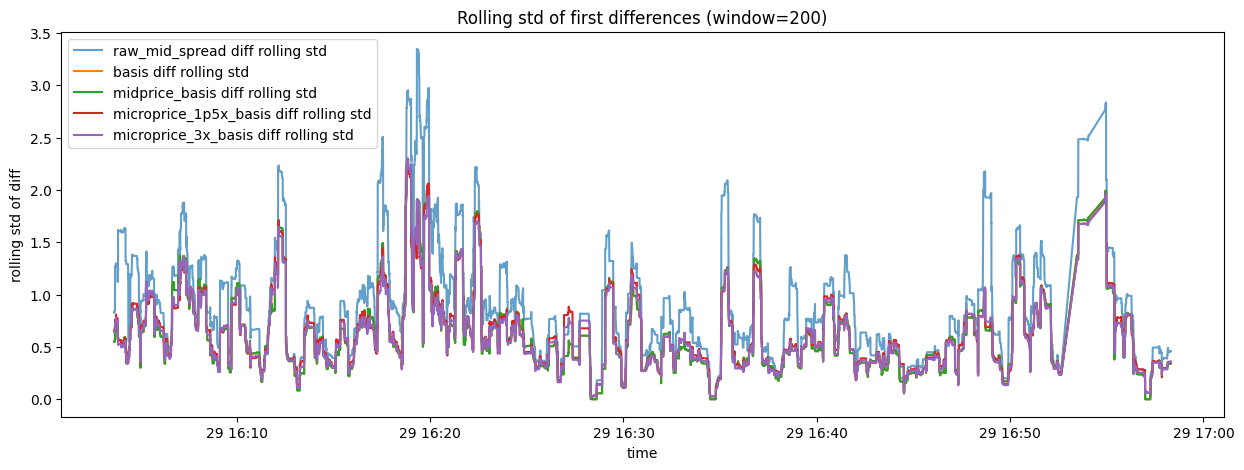

In [11]:
# Cell 11: rolling volatility / jitter view

window = 200

plt.figure(figsize=(15, 5))
if "raw_mid_spread" in df.columns:
    plt.plot(
        df["ts"],
        df["raw_mid_spread"].diff().rolling(window).std(),
        label="raw_mid_spread diff rolling std",
        alpha=0.7,
    )

for c in candidate_basis_cols:
    plt.plot(
        df["ts"],
        df[c].diff().rolling(window).std(),
        label=f"{c} diff rolling std",
    )

plt.title(f"Rolling std of first differences (window={window})")
plt.xlabel("time")
plt.ylabel("rolling std of diff")
plt.legend()
plt.show()

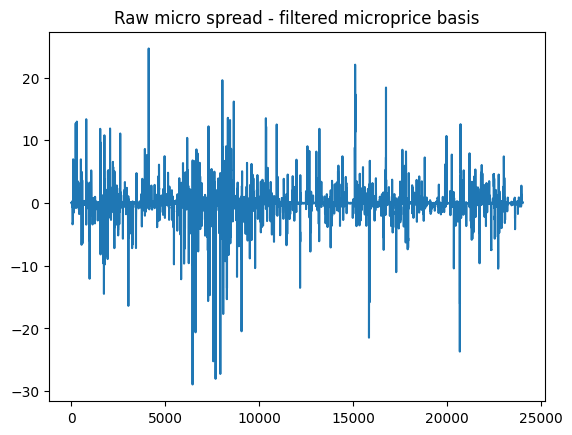

In [15]:
plt.plot(df.raw_micro_spread - df.microprice_1p5x_basis)
plt.title("Raw micro spread - filtered microprice basis")
plt.show()

Text(0.5, 1.0, 'Raw mid spread - filtered midprice basis')

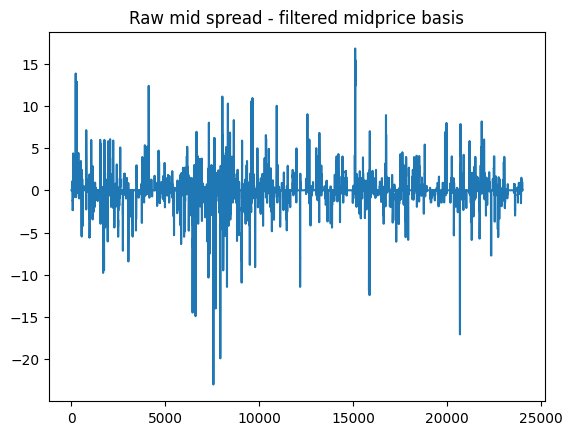

In [16]:
plt.plot(df.raw_mid_spread - df.basis)
plt.title("Raw mid spread - filtered midprice basis")